# Minnesota Hail Reports 07-31-2024

/tmp/ipykernel_22122/2292645246.py:21: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.
  ax0 = plt.subplot(1, 2, 1, projection=ccrs.LambertConformal())


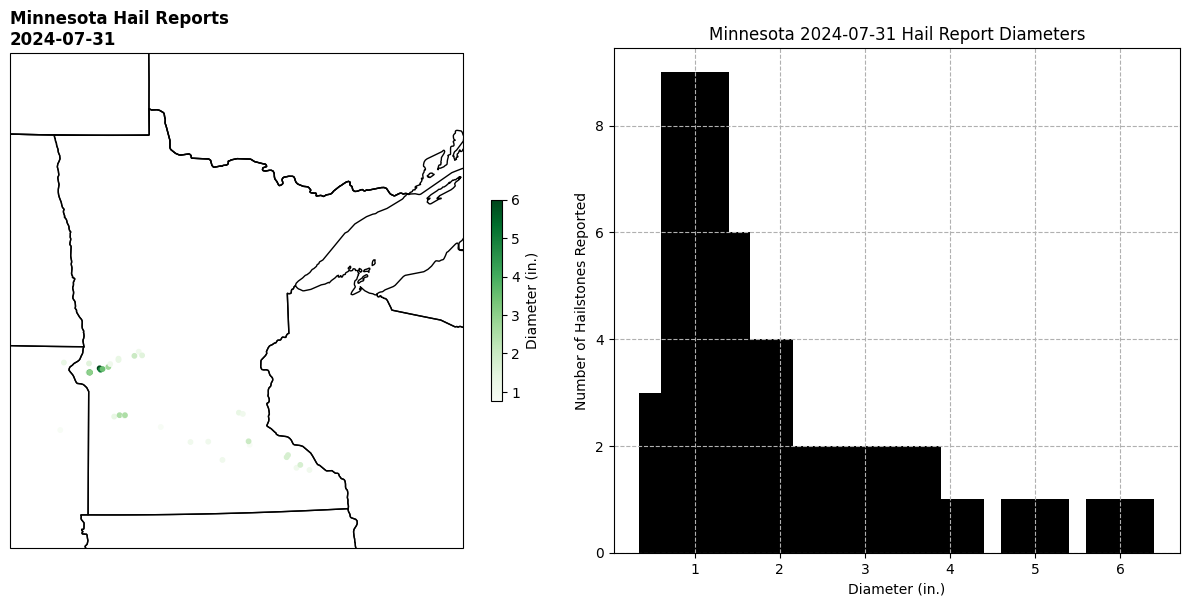

In [1]:
#import necessary packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

#read in the file
hail = pd.read_csv("1955-2024_hail.csv")

#filter data to July 31st, 2024
hail_24 = hail[(hail['dy'] == 31) & (hail['mo'] == 7) & (hail['yr'] == 2024)]

#filtering for latitude and Longitude around Minnesota
hail_mn = hail_24[(hail_24['slat'] >= 43.50) & (hail_24['slat'] <= 49.38) & (hail_24['slon'] >= -97.24) & (hail_24['slon'] <= -89.49)]


#plotting code
fig, (ax0, ax_bar) = plt.subplots(1, 2, figsize=(12, 6))

ax0 = plt.subplot(1, 2, 1, projection=ccrs.LambertConformal())
ax0.set_extent([-98, -89, 43, 50])

plot = ax0.scatter(hail_mn['slon'], hail_mn['slat'], c = hail_mn['mag'], cmap = 'Greens', s = 10, transform=ccrs.PlateCarree())

ax0.add_feature(cfeature.BORDERS)
ax0.add_feature(cfeature.COASTLINE)
ax0.add_feature(cfeature.STATES)

plt.colorbar(plot, ax=ax0, shrink = 0.4, label = "Diameter (in.)")
plt.title("Minnesota Hail Reports \n2024-07-31", fontweight="bold", loc = "left")



ax_bar = plt.subplot(1, 2, 2)
diameter = hail_mn.groupby('mag').size()

ax_bar.bar(diameter.index, diameter.values, color='black')
ax_bar.set_xlabel("Diameter (in.)")
ax_bar.set_ylabel("Number of Hailstones Reported")
ax_bar.set_title("Minnesota 2024-07-31 Hail Report Diameters")
ax_bar.grid(linestyle='dashed')


plt.tight_layout()
plt.savefig('figure_1.jpg', dpi=300)
plt.show()